In [2]:
import pandas as pd
import numpy as np

players_fresh_final = pd.read_csv('../data/players_fresh_final.csv')
players_fresh_final['log_value'] = np.log1p(players_fresh_final['current_value'])

In [3]:
from sklearn.model_selection import train_test_split

X = players_fresh_final.drop(columns=['current_value', 'log_value'])
y = players_fresh_final['log_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)} samples, Test: {len(X_test)} samples")

Train: 4468 samples, Test: 1117 samples


In [4]:
from sklearn.metrics import mean_squared_error, r2_score

mean_pred = np.full_like(y_test, y_train.mean())
mean_mse = mean_squared_error(y_test, mean_pred)
mean_r2 = r2_score(y_test, mean_pred)
print(f"Mean model - MSE: {mean_mse:.3f}, R2: {mean_r2:.3f}")

Mean model - MSE: 2.974, R2: -0.000


In [5]:
median_pred = np.full_like(y_test, y_train.median())
median_mse = mean_squared_error(y_test, median_pred)
median_r2 = r2_score(y_test, median_pred)
print(f"Median model - MSE: {median_mse:.3f}, R2: {median_r2:.3f}")

Median model - MSE: 3.058, R2: -0.028


In [6]:
from sklearn.linear_model import LinearRegression

age_model = LinearRegression()
age_model.fit(X_train[['age']], y_train)
age_pred = age_model.predict(X_test[['age']])
age_mse = mean_squared_error(y_test, age_pred)
age_r2 = r2_score(y_test, age_pred)
print(f"Age model - MSE: {age_mse:.3f}, R2: {age_r2:.3f}")

Age model - MSE: 2.957, R2: 0.006


In [7]:
minutes_model = LinearRegression()
minutes_model.fit(X_train[['total_minutes']], y_train)
minutes_pred = minutes_model.predict(X_test[['total_minutes']])
minutes_mse = mean_squared_error(y_test, minutes_pred)
minutes_r2 = r2_score(y_test, minutes_pred)
print(f"Minutes model - MSE: {minutes_mse:.3f}, R2: {minutes_r2:.3f}")

Minutes model - MSE: 2.775, R2: 0.067


In [8]:
results = pd.DataFrame({
    'Model': ['Mean baseline', 'Median baseline', 'Age-only', 'Minutes-only'],
    'RMSE': [np.sqrt(mean_mse), np.sqrt(median_mse), np.sqrt(age_mse), np.sqrt(minutes_mse)],
    'R2': [mean_r2, median_r2, age_r2, minutes_r2]
})
print(results)
print(X_train.isna().sum())
print(X_train.dtypes)

             Model      RMSE        R2
0    Mean baseline  1.724615 -0.000007
1  Median baseline  1.748758 -0.028201
2         Age-only  1.719678  0.005710
3     Minutes-only  1.665687  0.067164
player_id                 0
name                      0
current_date              0
peak_value                0
peak_date                 0
days_since_update         0
is_stale                  0
total_goals               0
total_assists             0
total_minutes             0
total_appearances         0
total_yellow_cards        0
total_red_cards           0
goals_per_90              0
assists_per_90            0
date_of_birth             0
position                  0
sub_position              0
foot                      0
height_in_cm              0
country_of_citizenship    0
age                       0
dtype: int64
player_id                   int64
name                          str
current_date                  str
peak_value                  int64
peak_date                     str
days_s

In [9]:
players_fresh_final['age_squared'] = players_fresh_final['age'] ** 2

feature_cols = ['age', 'age_squared', 'goals_per_90', 'assists_per_90', 'total_minutes', 'position']
X_full = players_fresh_final[feature_cols]
y_full = players_fresh_final['log_value']

In [10]:
X_full = pd.get_dummies(X_full, columns=['position'], drop_first=True)
print(X_full.columns.tolist()) #position_atack is a base position, so it is dropped to avoid multicollinearity
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

['age', 'age_squared', 'goals_per_90', 'assists_per_90', 'total_minutes', 'position_Defender', 'position_Goalkeeper', 'position_Midfield']


In [11]:
linear_model = LinearRegression()
linear_model.fit(X_train_full, y_train_full)
linear_pred = linear_model.predict(X_test_full)

linear_mse = mean_squared_error(y_test_full, linear_pred)
linear_r2 = r2_score(y_test_full, linear_pred)
print(f"Linear Regression model - RMSE: {np.sqrt(linear_mse):.3f}, R2: {linear_r2:.3f}")

Linear Regression model - RMSE: 1.414, R2: 0.328


In [12]:
from sklearn.linear_model import Lasso, Ridge

lasso_model = Lasso(alpha=0.01, random_state=42)
lasso_model.fit(X_train_full, y_train_full)
lasso_pred = lasso_model.predict(X_test_full)
lasso_rmse = np.sqrt(mean_squared_error(y_test_full, lasso_pred))
lasso_r2 = r2_score(y_test_full, lasso_pred)
print(f"Lasso — RMSE: {lasso_rmse:.3f}, R2: {lasso_r2:.3f}")#lasso can nullify some coefficients, which can be useful for feature selection

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_full, y_train_full)
ridge_pred = ridge_model.predict(X_test_full)
ridge_rmse = np.sqrt(mean_squared_error(y_test_full, ridge_pred))
ridge_r2 = r2_score(y_test_full, ridge_pred)
print(f"Ridge — RMSE: {ridge_rmse:.3f}, R2: {ridge_r2:.3f}")#ridge can help with multicollinearity by adding a penalty to the size of the coefficients(reduce but not nullify them)

Lasso — RMSE: 1.412, R2: 0.330
Ridge — RMSE: 1.414, R2: 0.328


Random Forest model, with cross-validation

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train_full, y_train_full)
rf_pred = rf_model.predict(X_test_full)

rf_rmse = np.sqrt(mean_squared_error(y_test_full, rf_pred))
rf_r2 = r2_score(y_test_full, rf_pred)
print(f"Random Forest — RMSE: {rf_rmse:.3f}, R2: {rf_r2:.3f}")


Random Forest — RMSE: 1.159, R2: 0.549


In [14]:
cs_scores = cross_val_score(rf_model, X_full, y_full, cv=5, scoring='r2')
print(f"Random Forest cross-validated R2 scores: {cs_scores}")
print(f"Random Forest mean cross-validated R2 score: {cs_scores.mean():.3f}, std: {cs_scores.std():.3f}")

Random Forest cross-validated R2 scores: [0.55882648 0.49174878 0.47940069 0.48710275 0.57954702]
Random Forest mean cross-validated R2 score: 0.519, std: 0.041


In [15]:
#feature importance
importances = pd.Series(rf_model.feature_importances_, index=X_train_full.columns)
print(importances.sort_values(ascending=False))

total_minutes          0.454041
age                    0.194105
age_squared            0.172381
goals_per_90           0.081943
assists_per_90         0.073667
position_Midfield      0.010803
position_Defender      0.009269
position_Goalkeeper    0.003791
dtype: float64


In [16]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_dist, cv=5, scoring='r2', n_iter=10, random_state=42, n_jobs=-1)
rf_search.fit(X_train_full, y_train_full)
print(f"Best params: {rf_search.best_params_}")

rf_best = rf_search.best_estimator_
rf_best_pred = rf_best.predict(X_test_full)
rf_best_rmse = np.sqrt(mean_squared_error(y_test_full, rf_best_pred))
rf_best_r2 = r2_score(y_test_full, rf_best_pred)
print(f"Tuned Random Forest — RMSE: {rf_best_rmse:.3f}, R2: {rf_best_r2:.3f}")

Best params: {'n_estimators': 300, 'min_samples_leaf': 4, 'max_depth': 10}
Tuned Random Forest — RMSE: 1.123, R2: 0.576


In [17]:
#final table of results

results = pd.DataFrame({
    'Model': ['Mean baseline', 'Median baseline', 'Age-only', 'Minutes-only', 'Linear Regression', 'Lasso', 'Ridge', 'Random Forest', 'Tuned Random Forest'],
    'RMSE': [np.sqrt(mean_mse), np.sqrt(median_mse), np.sqrt(age_mse), np.sqrt(minutes_mse), np.sqrt(linear_mse), lasso_rmse, ridge_rmse, rf_rmse, rf_best_rmse],
    'R2': [mean_r2, median_r2, age_r2, minutes_r2, linear_r2, lasso_r2, ridge_r2, rf_r2, rf_best_r2]
}) 
print(results)
compare_results = results.sort_values(by='R2', ascending=False)
print(compare_results)

                 Model      RMSE        R2
0        Mean baseline  1.724615 -0.000007
1      Median baseline  1.748758 -0.028201
2             Age-only  1.719678  0.005710
3         Minutes-only  1.665687  0.067164
4    Linear Regression  1.413626  0.328127
5                Lasso  1.412085  0.329590
6                Ridge  1.413542  0.328206
7        Random Forest  1.158756  0.548557
8  Tuned Random Forest  1.123338  0.575733
                 Model      RMSE        R2
8  Tuned Random Forest  1.123338  0.575733
7        Random Forest  1.158756  0.548557
5                Lasso  1.412085  0.329590
6                Ridge  1.413542  0.328206
4    Linear Regression  1.413626  0.328127
3         Minutes-only  1.665687  0.067164
2             Age-only  1.719678  0.005710
0        Mean baseline  1.724615 -0.000007
1      Median baseline  1.748758 -0.028201


# Model comparison summary

Tuned Random Forest is the best model (R2=0.576, RMSE=1.123).

This matches what is in EDA, total_minutes dominates (0.454). Age and age_squared combined contribute 0.37 of importance, so earlier decision to include the non-linear age term is solid.

Position dummies contribute almost nothing (<0.01), matching the earlier observation that Attack/Defender/Midfield showed surprisingly similar value distributions in EDA.
goals_per_90 (0.082) and assists_per_90 (0.074) have less weight than total_minutes, so playing time may be a stronger value signal.

In [18]:
residuals = y_test_full - rf_best_pred
residual_df = players_fresh_final.loc[X_test_full.index, ['name', 'position', 'age', 'total_minutes']].copy()
residual_df['actual_log_value'] = y_test_full
residual_df['predicted_log_value'] = rf_best_pred
residual_df['residual'] = residuals

<Axes: >

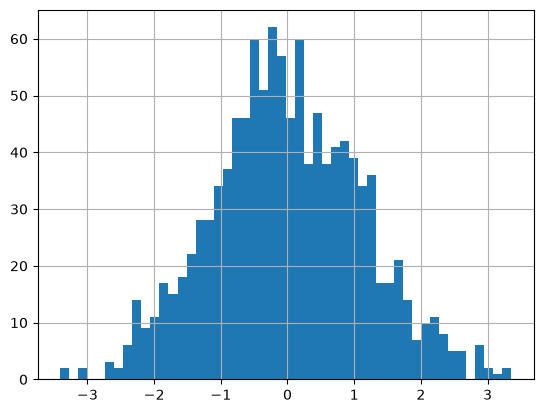

In [19]:
residual_df['residual'].hist(bins=50)

In [20]:
print("Most overvalued (actual >> predicted):")
print(residual_df.sort_values('residual', ascending=False).head(10))

print("Most undervalued (actual << predicted):")
print(residual_df.sort_values('residual').head(10))

Most overvalued (actual >> predicted):
                 name  position        age  total_minutes  actual_log_value  \
737      Jay Robinson    Attack  18.721424            135         15.894952   
4494      Wisdom Mike    Attack  17.234771             22         15.424949   
5004   Vasilije Adžić  Midfield  19.616701            299         15.894952   
746    Jay Stansfield    Attack  23.025325            730         16.705882   
5010      Petar Sučić  Midfield  22.162902           1542         17.216708   
721     Jacob Greaves  Defender  25.223819           2279         16.588099   
1544             Biel    Attack  24.692676             86         15.319588   
5005  Niccolò Fortini  Defender  19.857632            447         16.118096   
4896    Ardon Jashari  Midfield  23.400411           3032         17.281246   
1101      Diego Gómez  Midfield  22.704997           1711         17.034386   

      predicted_log_value  residual  
737             12.541519  3.353434  
4494           

# Error analysis

1. Most overvalued by actual value. Nearly all top overvalued players (e.g. Jay Robinson, Wisdom Mike, Vasilije Adžić) are very young (18-25) with low total_minutes. So when they carry high real market value, the model underpredicts them because it has almost no performance signal to work with. Their prices are driven by potential, reputation, hype and young age, none of which are captured as features here.

2. Veterans overvalued by the model (most undervalued by actual value). Nearly all top undervalued players (e.g. Stephen O'Donnell, Bruce Anderson) are old (25-33) with very high career minutes (up to 26,092), but low actual market value.Since total_minutes is the model's most important feature (0.454 importance), the model overvalue their playing time. But the real market has already discounted these players for age-related decline, an effect age_squared captures only partially at these extremes.

The limitation of the model from both patterns is that the model has no feature about reputation, potential or market hype. And underweights how strongly age discounts value for  veterans specifically.

<Axes: title={'center': 'residual'}, xlabel='position'>

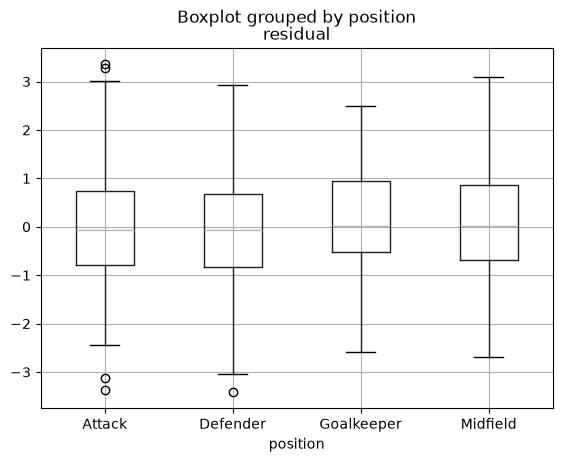

In [21]:
residual_df.boxplot(column='residual', by='position')

All 4 positions are centered close to 0. So there is no huge overall bias by position.
Goalkeeper boxplot is a bit higher(harder to predict, probably because goals_per_90/assists_per_90 mean almost nothing for keepers).
Attack and defender have a bit outliers(<-3), matching the same undervalued veterans found earlier

In [22]:
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
print(f"Residual skewness: {skew(residuals):.3f}")

Residual skewness: 0.094


Text(0, 0.5, 'Residual')

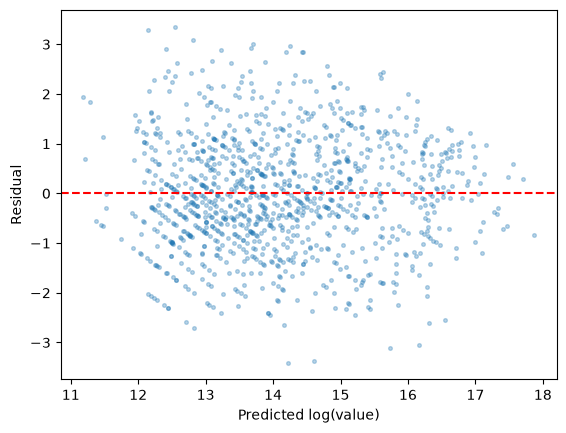

In [23]:
plt.scatter(rf_best_pred, residuals, alpha=0.3, s=7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted log(value)')
plt.ylabel('Residual')

Residual distribution is almost symmetric (skewness 0.094 is close to 0). This indicates the models errors are unbiased and not skewed toward over- or under-prediction, a well-calibrated result.

In [24]:
import joblib
final_model = RandomForestRegressor(**rf_search.best_params_, random_state=42)
final_model.fit(X_full, y_full)

players_fresh_final['predicted_log_value'] = final_model.predict(X_full)
players_fresh_final['residual'] = players_fresh_final['log_value'] - players_fresh_final['predicted_log_value']

joblib.dump(final_model, '../app/model.pkl')
players_fresh_final.to_csv('../app/dashboard_data.csv', index=False)

In [25]:
dashboard_data = pd.read_csv("../app/dashboard_data.csv")

print("Most overvalued (actual >> predicted):")
print(dashboard_data.sort_values('residual', ascending=False).head(10))

print("Most undervalued (actual << predicted):")
print(dashboard_data.sort_values('residual').head(10))

Most overvalued (actual >> predicted):
      player_id                 name  current_value current_date  peak_value  \
745      864121         Abdul Fatawu       20000000   2025-12-03    20000000   
671      596446           Leif Davis       20000000   2025-12-03    25000000   
688      665390      Jaden Philogene       18000000   2025-12-03    18000000   
1349     345911      Ladislav Krejci       22000000   2025-12-09    22000000   
1901     964087       Alphadjo Cissè        6000000   2025-12-11     6000000   
5280     856274  Jonathan Asp Jensen        4000000   2025-12-29     4000000   
682      646353       Carl Rushworth        6000000   2025-12-03     6000000   
728      956920    Nestory Irankunda        6000000   2025-12-03     6000000   
737     1045124         Jay Robinson        8000000   2025-12-03     8000000   
1544     875328                 Biel        4500000   2025-12-10     5000000   

       peak_date  days_since_update  is_stale  total_goals  total_assists  \
745

In [26]:
from sklearn.model_selection import cross_val_predict

best_rf = RandomForestRegressor(**rf_search.best_params_, random_state=42)
oof_predictions = cross_val_predict(best_rf, X_full, y_full, cv=5)

players_fresh_final['predicted_log_value'] = oof_predictions
players_fresh_final['residual'] = players_fresh_final['log_value'] - oof_predictions

print("Most undervalued (actual << predicted):")
print(players_fresh_final.sort_values('residual').head(10))

Most undervalued (actual << predicted):
      player_id              name  current_value current_date  peak_value  \
2564    1046648  Lukas Kirkegaard          25000   2025-12-15       25000   
82       418891  Oleksandr Melnyk          25000   2025-06-10      300000   
2631     926992         Max Albæk          25000   2025-12-15       25000   
4470     935047     Kyrylo Sigeev         150000   2025-12-19      600000   
3607     890055     Gustav Bjerge          25000   2025-12-18       25000   
3764    1136724  Maksym Radchenko          10000   2025-12-18       10000   
3565     726038     Vitaliy Roman         500000   2025-12-18      800000   
2574    1079965  Frederik Damkjer          75000   2025-12-15       75000   
5290    1201294     Ozan Demirbağ         175000   2025-12-29      175000   
151      383198     Ilya Shevtsov          75000   2025-10-21      400000   

       peak_date  days_since_update  is_stale  total_goals  total_assists  \
2564  2025-09-02                 74

In [27]:
final_model = RandomForestRegressor(**rf_search.best_params_, random_state=42)
final_model.fit(X_full, y_full)
joblib.dump(final_model, '../app/model.pkl')

players_fresh_final.to_csv('../app/dashboard_data.csv', index=False)

Initially the model was trained on 100% of data, and used its own predictions for analysis, but this produced predictions where the model had already seen each player's true value during training. Fixed by using cross_val_predict to generate honest predictions for every player.

In [28]:
print(dashboard_data.loc[[2564, 82, 2631, 4470, 3607], ['name', 'total_minutes', 'goals_per_90', 'assists_per_90']])

                  name  total_minutes  goals_per_90  assists_per_90
2564  Lukas Kirkegaard            548      0.164234        0.328467
82    Oleksandr Melnyk           3337      0.000000        0.000000
2631         Max Albæk            138      0.652174        0.000000
4470     Kyrylo Sigeev           3549      0.050719        0.050719
3607     Gustav Bjerge            270      0.000000        0.000000


In [29]:
print(dashboard_data.sort_values('residual').head(30)['country_of_citizenship'].value_counts())

country_of_citizenship
Ukraine        9
Scotland       6
Denmark        5
Türkiye        4
Netherlands    1
Wales          1
Spain          1
Mali           1
Curacao        1
Belgium        1
Name: count, dtype: int64


**3. Market/league tier not captured:** 80% (24/30) of the most 
undervalued players by residual come from just four countries: Ukraine (9), 
Scotland (6), Denmark (5), and Türkiye (4), despite having reasonable per-90 
stats. Country/league market tier isn't included as a model feature, so the 
model predicts what a player "should" be worth based purely on performance 
stats, without accounting for smaller football markets being systematically 
valued lower by Transfermarkt regardless of underlying performance.

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
gb_oof = cross_val_predict(gb_model, X_full, y_full, cv=5)
gb_r2 = r2_score(y_full, gb_oof)
print(f"Gradient Boosting CV R²: {gb_r2:.3f}")

top_100_idx = players_fresh_final.nlargest(100, 'current_value').index
gb_residuals = players_fresh_final.loc[top_100_idx, 'log_value'] - gb_oof[top_100_idx]
print(f"GB mean residual (top 100): {gb_residuals.mean():.3f}")

Gradient Boosting CV R²: 0.558
GB mean residual (top 100): 1.175


**4. Systematic underprediction at the top of the value range:** Among the 100 most expensive players in the dataset, 100% have a positive residual (mean +1.246). This is a known behavior of tree-based ensemble models like Random Forest: predictions are built by averaging across many trees, which naturally pulls extreme values toward the center of the distribution rather than predicting equally extreme outputs. Combined with Pattern 1 (young players with minimal stats overvalued by the market), this suggests the model struggles most at both tails of the value distribution. It is most reliable for the broad middle of the market, and least reliable at the very top and very bottom.

In [31]:
df = pd.read_csv('../app/dashboard_data.csv') 

bins = [0, 100_000, 500_000, 1_000_000, 5_000_000, 20_000_000, 50_000_000, 250_000_000]
df['value_bucket'] = pd.cut(df['current_value'], bins=bins)
print(df.groupby('value_bucket')['residual'].agg(['mean', 'count']))

                           mean  count
value_bucket                          
(0, 100000]           -1.516816    356
(100000, 500000]      -0.643274   1542
(500000, 1000000]     -0.186016    910
(1000000, 5000000]     0.342677   1575
(5000000, 20000000]    0.894197    800
(20000000, 50000000]   1.081971    325
(50000000, 250000000]  1.296826     77


the model overvalues cheap players and undervalues expensive ones, with mean residual moving from -1.52 (players under €100K) to +1.30 (players over €50M)